In [ ]:
import tensorflow as tf #สร้าง neural network
from tensorflow.keras import layers, models #Conv2D, MaxPooling, etc #model = รวม layer เป็นโมเดล
import numpy as np
import matplotlib.pyplot as plt #เอาไว้โชว์รูป

In [ ]:
#โหลด CIFAR-10 Dataset from online
(x_train,_),(x_test,_)=tf.keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [ ]:
print(x_train.shape)
print(x_test.shape)
#show size dataset

(50000, 32, 32, 3)
(10000, 32, 32, 3)


In [ ]:
x_train = x_train.astype('float32')/255
x_test = x_test.astype('float32')/255
#Normalize image

In [ ]:
#Dense Block
def dense_block(x, filters, layers_in_block=2):
    for i in range(layers_in_block):
        out = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
        x = layers.Concatenate()([x, out])
    return x


In [ ]:
#Input → Conv → concat(Input)
      #→ Conv → concat(Input + Conv1)
#Dense Block = เอาผลของทุก layer มา concat รวมกัน

In [ ]:
#Residual Box = เรียนรู้เฉพาะส่วนที่ “ต่างจากเดิม”
#formula = > output = F(x) + x

def residual_block(x, filters):
    shortcut = x

    x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
    x = layers.Conv2D(filters, 3, padding="same")(x)

    # ปรับ shortcut ถ้า channel ไม่เท่ากัน
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, padding="same")(shortcut)

    x = layers.add([shortcut, x])
    x = layers.Activation("relu")(x)

    return x


In [ ]:
# Create Encoder
#Input : 32x32x3
# Conv -> ดึง feature
# Maxpool -> ลดเหลือ 16x16x64
# Dense + Residual
# 8x8x32 (latent space)edit to 16x16x32
input_img = layers.Input(shape=(32,32,3))

x=layers.Conv2D(32, 3, padding="same", activation="relu")(input_img)
x=layers.MaxPool2D((2,2), padding="same")(x)

In [ ]:
#ใส่ Dense + Residual Block
x = dense_block(x, 32)
x = residual_block(x, 32)
encoded = x

In [ ]:
# create Decoder
# 8×8×32
#→ 16×16×32
#→ Residual refine
#→ 32×32×3
# Decoder
# 16×16×32 → 32×32×32
x = layers.Conv2D(32, 3, padding="same", activation="relu")(encoded)
x = layers.UpSampling2D((2,2))(x)

x = residual_block(x, 32)

decoded = layers.Conv2D(3, 3, padding="same", activation="sigmoid")(x)

In [ ]:
# sumarize to Autoencoder
autoencoder = models.Model(input_img, decoded)
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 32, 32,    │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 16, 16,    │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 16, 16,    │      9,248 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 16, 16,    │          0 │ max_pooling2d[0]… │
│ (Concatenate)       │ 64)               │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 16, 16,    │     18,464 │ concatenate[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 16, 16,    │          0 │ concatenate[0][0… │
│ (Concatenate)       │ 96)               │            │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 16, 16,    │     27,680 │ concatenate_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 16, 16,    │      3,104 │ concatenate_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 16, 16,    │      9,248 │ conv2d_3[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 16, 16,    │          0 │ conv2d_5[0][0],   │
│                     │ 32)               │            │ conv2d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 16, 16,    │          0 │ add[0][0]         │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │      9,248 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 32, 32,    │          0 │ conv2d_6[0][0]    │
│ (UpSampling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │      9,248 │ up_sampling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 32, 32,    │      9,248 │ conv2d_7[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 32, 32,    │          0 │ up_sampling2d[0]

 Total params: 97,251 (379.89 KB)

 Trainable params: 97,251 (379.89 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
autoencoder.compile(
    optimizer="adam",
    loss="mse"
)
#บอกโมเดลว่า
# - > จะใช้วิธีปรับน้ำหนักแบบไหน (adam)
# - > จะวัดความผิดพลาดยังไง (mse)

In [ ]:
# train model and ready to learning
history = autoencoder.fit(
    x_train,
    x_train,
    epochs=50,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test, x_test)
)

Epoch 1/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 21s 33ms/step - loss: 0.0154 - val_loss: 0.0020
Epoch 2/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - loss: 0.0017 - val_loss: 0.0013
Epoch 3/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - loss: 0.0012 - val_loss: 9.5675e-04
Epoch 4/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - loss: 0.0010 - val_loss: 8.4564e-04
Epoch 5/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - loss: 8.9142e-04 - val_loss: 7.5398e-04
Epoch 6/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - loss: 7.9121e-04 - val_loss: 7.0312e-04
Epoch 7/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - loss: 7.2682e-04 - val_loss: 6.6830e-04
Epoch 8/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - loss: 7.2592e-04 - val_loss: 6.3034e-04
Epoch 9/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - loss: 6.5745e-04 - val_loss: 6.2992e-04
Epoch 10/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - loss: 6.0633e-04 - val_loss: 5.9413e-04
Epoch 11/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - loss: 5.8933e-0

In [ ]:
decoded_imgs = autoencoder.predict(x_test)
#โมเดลเอา x_test เข้า
#สร้างภาพใหม่ที่พยายาม “เหมือนเดิมที่สุด”
#เก็บผลไว้ใน decoded_imgs

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


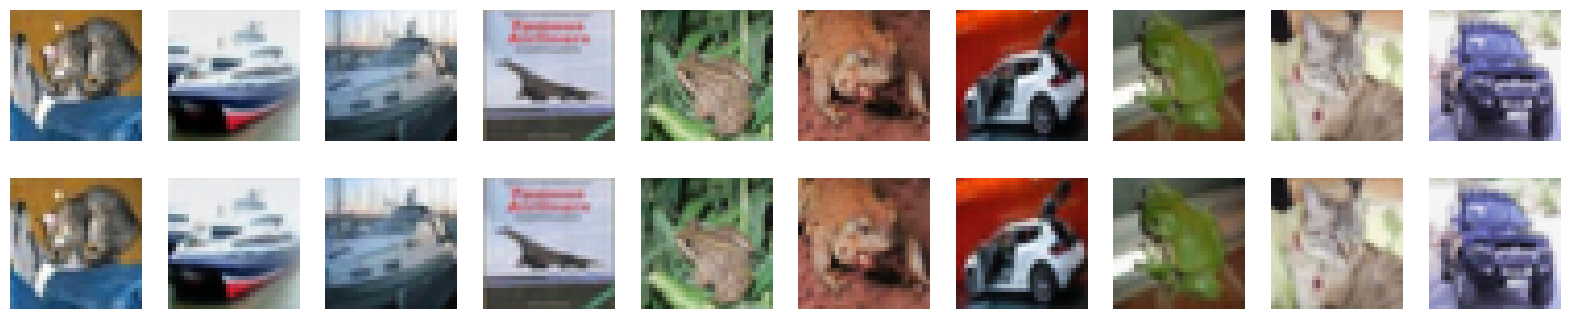

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20,4))
for i in range(10):
    # ภาพจริง
    plt.subplot(2, 10, i+1)
    plt.imshow(x_test[i])
    plt.axis("off")

    # ภาพที่โมเดลสร้าง
    plt.subplot(2, 10, i+11)
    plt.imshow(decoded_imgs[i])
    plt.axis("off")

plt.show()
#แถวบน = ภาพจริง
#แถวล่าง = ภาพที่ reconstruct

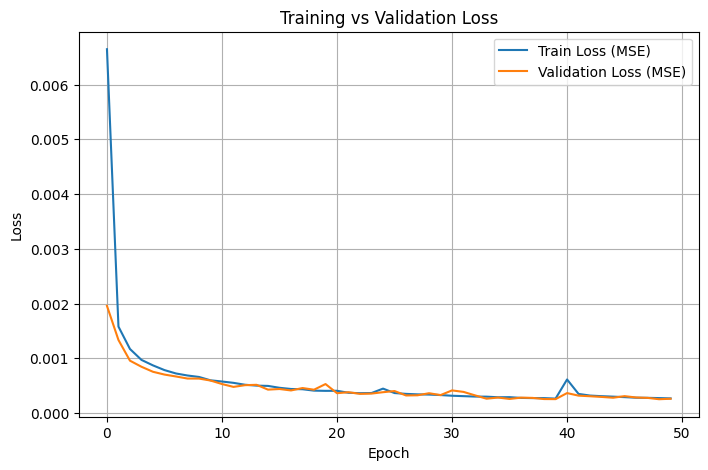

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Train Loss (MSE)")
plt.plot(history.history["val_loss"], label="Validation Loss (MSE)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
print("=== Training Statistics ===")
print(f"Final Train Loss (MSE): {history.history['loss'][-1]:.6f}")
print(f"Final Validation Loss (MSE): {history.history['val_loss'][-1]:.6f}")

if 'mae' in history.history:
    print(f"Final Train MAE: {history.history['mae'][-1]:.6f}")
    print(f"Final Validation MAE: {history.history['val_mae'][-1]:.6f}")


=== Training Statistics ===
Final Train Loss (MSE): 0.000268
Final Validation Loss (MSE): 0.000261


| ส่วน           | ทำหน้าที่          |
| -------------- | ------------------ |
| Conv           | มองรายละเอียด      |
| Pool           | ย่อภาพ             |
| Dense Block    | จำทุกอย่าง         |
| Residual Block | แก้เฉพาะที่ต้องแก้ |
| Latent         | ความทรงจำ          |
| UpSampling     | ขยายกลับ           |
| Output Conv    | วาดภาพจริง         |


สรุปแบบตาราง (ก่อน vs หลัง)

| จุดที่ปรับ                | ก่อน        | หลัง                  | ผลที่เกิด             |
| ------------------------- | ----------- | --------------------- | --------------------- |
| ขนาด latent space         | 8×8×32      | **16×16×32**          | รายละเอียดภาพกลับมา   |
| จำนวน MaxPooling          | 2 ครั้ง     | **1 ครั้ง**           | ไม่บีบภาพแรงเกิน      |
| ความสมดุล Encoder–Decoder | ไม่สมดุล    | **สมดุล**             | reconstruction เสถียร |
| ภาระ Decoder              | ต้องเดาเยอะ | **เดาน้อยลง**         | ภาพเนียน              |
| ค่า MSE                   | สูงกว่า     | **ต่ำมาก (~0.00026)** | คุณภาพดี              |


สรุปบทบาท Activation แบบจำง่าย

| Layer          | Activation | หน้าที่             |
| -------------- | ---------- | ------------------- |
| Encoder Conv   | ReLU       | เลือก feature สำคัญ |
| Dense Block    | ReLU       | เก็บเฉพาะลายละเอียด |
| Residual Block | ReLU       | แก้เฉพาะจุด         |
| Output Conv    | Sigmoid    | คุมค่าสีภาพ         |


Conv = มอง

Pool = ย่อ

Dense = จำ

Residual = รีทัช

Activation = ตัดสินใจ